# Session-Halving Notebook — Three Pipeline Variants

Every session is **split into two equal halves** before feature extraction,
doubling the training set from 24 to up to 48 samples.

Three pipelines are compared:

| # | Pipeline | Description |
|---|---|---|
| 1 | **Baseline** | Halved, no filter |
| 2 | **Bandpass** | Halved + Butterworth bandpass 0.5–6 Hz |
| 3 | **Bandpass + Movement excl.** | Halved + bandpass + adaptive segment exclusion |

In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, butter, sosfiltfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

COLORS = {'Apfel':'#e15759','Kaugummi':'#4e79a7','Skyr':'#f28e2b','Still':'#59a14f'}

## 1. Load & Preprocess

In [2]:
DATA_DIR  = Path('../data/raw')
CLASSES   = ['Apfel', 'Kaugummi', 'Skyr', 'Still']
FS        = 50.0
TRIM_SECS = 5

sessions = {cls: [] for cls in CLASSES}
for zf in sorted(DATA_DIR.glob('*.zip')):
    for cls in CLASSES:
        if zf.name.startswith(cls + '_'):
            sessions[cls].append(zf); break

min_available = min(len(v) for v in sessions.values())
N_SESSIONS = min_available
n = min(max(1, N_SESSIONS), min_available)
print(f'Using {n} sessions per class')

_SKIP = {'Metadata.csv', 'Annotation.csv'}
loaded = {}
for cls in CLASSES:
    loaded[cls] = []
    for zf in sessions[cls][:n]:
        with zipfile.ZipFile(zf) as z:
            csv_name = next(f for f in z.namelist()
                            if f.endswith('.csv') and f not in _SKIP)
            with z.open(csv_name) as f:
                loaded[cls].append(pd.read_csv(f))

def preprocess(df):
    df = df.copy()
    t = df['seconds_elapsed']
    df = df[(t >= t.iloc[0] + TRIM_SECS) & (t <= t.iloc[-1] - TRIM_SECS)].reset_index(drop=True)
    df['lin_x']     = df['accelerationX']
    df['lin_y']     = df['accelerationY']
    df['lin_z']     = df['accelerationZ']
    df['magnitude'] = np.sqrt(df['lin_x']**2 + df['lin_y']**2 + df['lin_z']**2)
    return df

preprocessed = {cls: [preprocess(df) for df in loaded[cls]] for cls in CLASSES}

print('Session durations after trim:')
for cls in CLASSES:
    durs = [df['seconds_elapsed'].iloc[-1] - df['seconds_elapsed'].iloc[0]
            for df in preprocessed[cls]]
    print(f'  {cls:12s}: {min(durs):.1f}–{max(durs):.1f} s')

Using 15 sessions per class
Session durations after trim:
  Apfel       : 50.8–52.9 s
  Kaugummi    : 50.8–56.5 s
  Skyr        : 50.8–51.9 s
  Still       : 50.9–51.5 s


## 2. Split into Halves

Each session is cut at its time midpoint. Halves shorter than 8 s are discarded.

In [3]:
MIN_HALF_SECS = 8

def split_halves(df):
    t = df['seconds_elapsed']
    tmid = (t.iloc[0] + t.iloc[-1]) / 2
    halves = [
        df[t <= tmid].reset_index(drop=True),
        df[t >  tmid].reset_index(drop=True),
    ]
    return [h for h in halves
            if len(h) > 0 and
            (h['seconds_elapsed'].iloc[-1] - h['seconds_elapsed'].iloc[0]) >= MIN_HALF_SECS]

halved = {cls: [] for cls in CLASSES}
for cls in CLASSES:
    for df in preprocessed[cls]:
        halved[cls].extend(split_halves(df))

print('Halves per class:')
for cls in CLASSES:
    durs = [df['seconds_elapsed'].iloc[-1] - df['seconds_elapsed'].iloc[0]
            for df in halved[cls]]
    print(f'  {cls:12s}: {len(halved[cls])} halves  '
          f'({min(durs):.1f}–{max(durs):.1f} s each)')

Halves per class:
  Apfel       : 30 halves  (25.4–26.4 s each)
  Kaugummi    : 30 halves  (25.4–28.2 s each)
  Skyr        : 30 halves  (25.4–25.9 s each)
  Still       : 30 halves  (25.4–25.7 s each)


## 3. Filter & Movement Exclusion Helpers

**Bandpass filter:** 4th-order zero-phase Butterworth, passband 0.5–6 Hz.
Preserves the chewing band (0.5–4 Hz) while removing DC drift and high-frequency noise.

**Adaptive movement exclusion:** `threshold = max(0.02, 5 × session_median)`.

In [4]:
BP_LOW, BP_HIGH = 0.5, 6.0  # Hz

def apply_bandpass(signal, low=BP_LOW, high=BP_HIGH, fs=FS, order=4):
    sos = butter(order, [low, high], btype='band', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

def apply_bp_to_df(df):
    df = df.copy()
    for col in ['lin_x', 'lin_y', 'lin_z']:
        df[col] = apply_bandpass(df[col].values)
    df['magnitude'] = np.sqrt(df['lin_x']**2 + df['lin_y']**2 + df['lin_z']**2)
    return df

def adaptive_threshold(df, k=5.0, global_min=0.02):
    return max(global_min, k * df['magnitude'].median())

def movement_mask(df, threshold=None, rolling_window=50):
    if threshold is None:
        threshold = adaptive_threshold(df)
    roll_max = df['magnitude'].rolling(rolling_window, center=True, min_periods=1).max()
    return roll_max <= threshold

print('Helpers defined: apply_bandpass, apply_bp_to_df, adaptive_threshold, movement_mask')

Helpers defined: apply_bandpass, apply_bp_to_df, adaptive_threshold, movement_mask


## 4. Feature Extraction

In [5]:
def extract_features(df):
    feats = {}
    for col in ['lin_x','lin_y','lin_z','magnitude']:
        feats[f'{col}_mean'] = df[col].mean()
        feats[f'{col}_std']  = df[col].std()
        feats[f'{col}_max']  = df[col].abs().max()
    feats['stillness_ratio'] = (df['magnitude'] < 0.02).mean()
    feats['movement_events'] = int((df['magnitude'] > df['magnitude'].quantile(0.75)).sum())
    for col in ['rotationRateX','rotationRateY','rotationRateZ']:
        feats[f'{col}_mean'] = df[col].mean()
        feats[f'{col}_std']  = df[col].std()
        feats[f'{col}_max']  = df[col].abs().max()
    for col in ['pitch','roll','yaw']:
        feats[f'{col}_mean']  = df[col].mean()
        feats[f'{col}_std']   = df[col].std()
        feats[f'{col}_range'] = df[col].max() - df[col].min()
    nperseg = min(256, len(df) // 2)
    freqs, psd = welch(df['magnitude'].values, fs=FS, nperseg=nperseg)
    chew = (freqs >= 0.5) & (freqs <= 4.0)
    cf, cp = freqs[chew], psd[chew]
    feats['total_power']        = float(psd.sum())
    feats['chew_band_power']    = float(cp.sum())
    feats['rhythmicity']        = feats['chew_band_power'] / feats['total_power'] if feats['total_power'] > 0 else 0.0
    feats['dominant_chew_freq'] = float(cf[np.argmax(cp)]) if len(cp) > 0 else 0.0
    return feats

def build_matrix(session_dict):
    rows, labels = [], []
    for cls in CLASSES:
        for df in session_dict[cls]:
            rows.append(extract_features(df))
            labels.append(cls)
    return pd.DataFrame(rows), np.array(labels)

def run_loo(X, y):
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    yt, yp = [], []
    for tr, te in LeaveOneOut().split(X):
        clf.fit(X.iloc[tr], y[tr])
        yp.append(clf.predict(X.iloc[te])[0])
        yt.append(y[te][0])
    return yt, yp

## 5. Pipeline 1 — Baseline (halved, no filter)

Raw halved sessions, no additional filtering.

In [6]:
X1, y1 = build_matrix(halved)
yt1, yp1 = run_loo(X1, y1)
acc1 = accuracy_score(yt1, yp1)
print(f'Pipeline 1 — Baseline:  {acc1:.1%}  ({int(acc1*len(yt1))}/{len(yt1)})')

Pipeline 1 — Baseline:  89.2%  (107/120)


## 6. Pipeline 2 — Bandpass Filter 0.5–6 Hz

Apply bandpass to lin\_x/y/z before recomputing magnitude and extracting features.

In [7]:
halved_bp = {cls: [apply_bp_to_df(df) for df in halved[cls]] for cls in CLASSES}

X2, y2 = build_matrix(halved_bp)
yt2, yp2 = run_loo(X2, y2)
acc2 = accuracy_score(yt2, yp2)
print(f'Pipeline 2 — Bandpass:  {acc2:.1%}  ({int(acc2*len(yt2))}/{len(yt2)})')

Pipeline 2 — Bandpass:  85.0%  (102/120)


## 7. Pipeline 3 — Bandpass + Movement Exclusion

Apply bandpass first, then remove movement segments with the adaptive threshold.

In [8]:
halved_bp_nomov = {cls: [] for cls in CLASSES}
for cls in CLASSES:
    for df in halved_bp[cls]:
        clean = df[movement_mask(df)].reset_index(drop=True)
        if len(clean) > 50:
            halved_bp_nomov[cls].append(clean)

print('Halves kept after movement exclusion:')
for cls in CLASSES:
    print(f'  {cls:12s}: {len(halved_bp_nomov[cls])}')

X3, y3 = build_matrix(halved_bp_nomov)
yt3, yp3 = run_loo(X3, y3)
acc3 = accuracy_score(yt3, yp3)
print(f'Pipeline 3 — BP + Mov. excl.:  {acc3:.1%}  ({int(acc3*len(yt3))}/{len(yt3)})')

Halves kept after movement exclusion:
  Apfel       : 30
  Kaugummi    : 30
  Skyr        : 30
  Still       : 30
Pipeline 3 — BP + Mov. excl.:  91.7%  (110/120)


## 10. Pipeline 4 — Movement Exclusion only (no bandpass)

For comparison: adaptive movement exclusion applied directly to the raw halved sessions,
without any frequency filtering.

In [9]:
halved_nomov = {cls: [] for cls in CLASSES}
for cls in CLASSES:
    for df in halved[cls]:
        clean = df[movement_mask(df)].reset_index(drop=True)
        if len(clean) > 50:
            halved_nomov[cls].append(clean)

X4, y4 = build_matrix(halved_nomov)
yt4, yp4 = run_loo(X4, y4)
acc4 = accuracy_score(yt4, yp4)
print(f"Pipeline 4 — Mov. excl. only:  {acc4:.1%}  ({int(acc4*len(yt4))}/{len(yt4)})")

Pipeline 4 — Mov. excl. only:  95.8%  (115/120)


## 8. Summary — Confusion Matrices

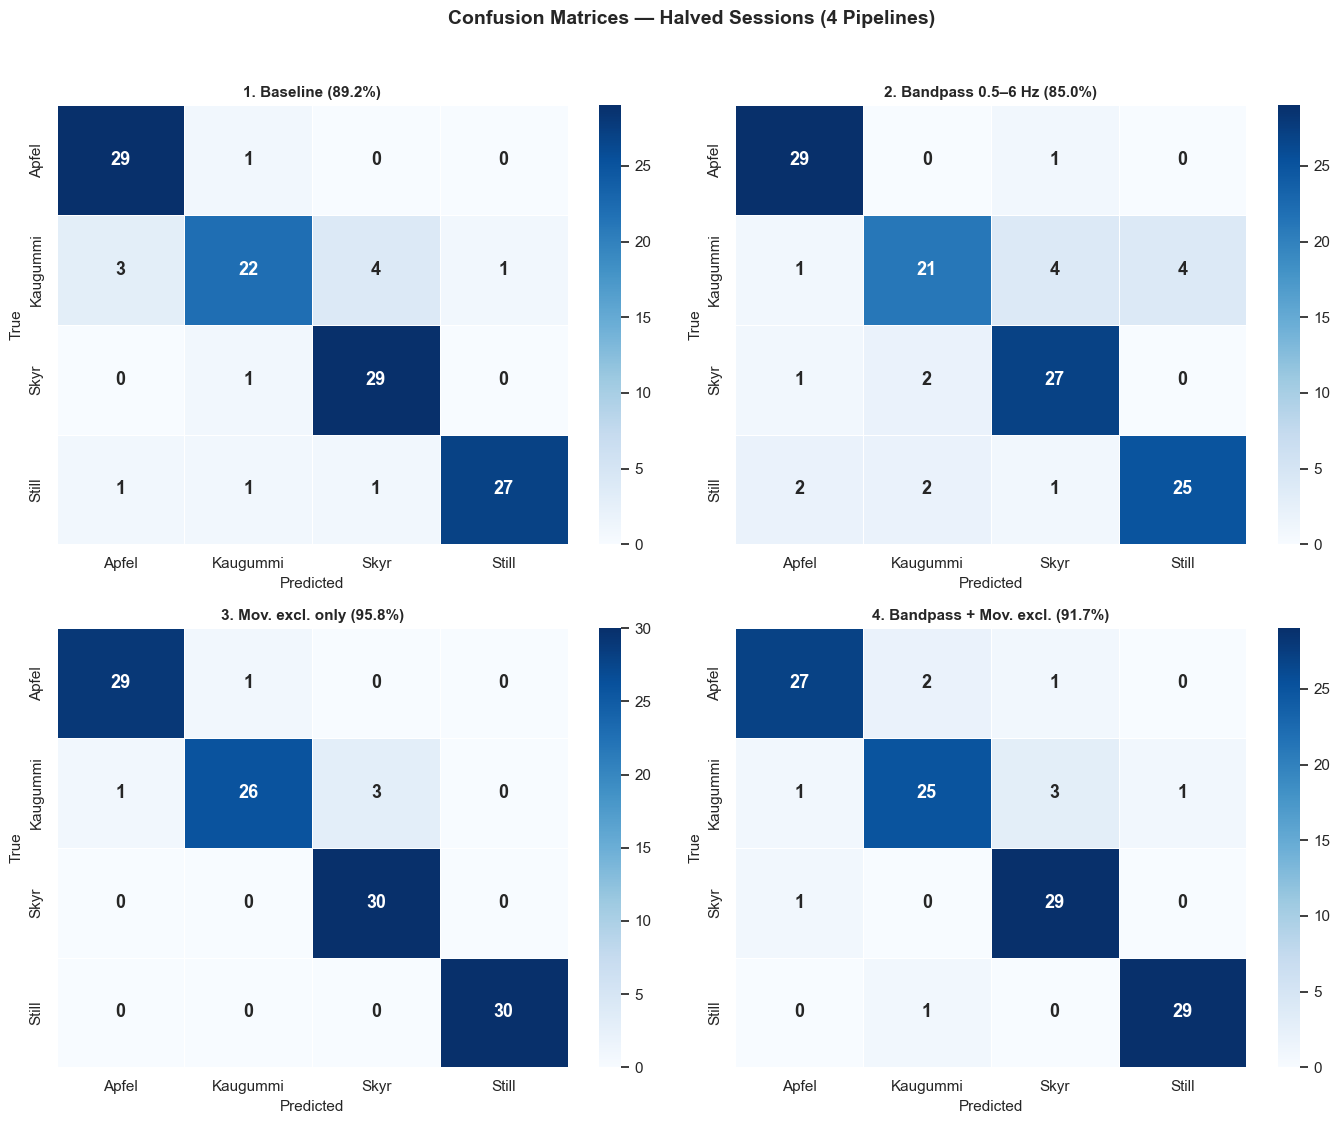

=== Accuracy summary ===
1. Baseline              : 89.2%  (107/120)
2. Bandpass 0.5-6 Hz     : 85.0%  (102/120)
3. Mov. excl. only       : 95.8%  (115/120)
4. BP + movement excl.   : 91.7%  (110/120)


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

quads = [
    (confusion_matrix(yt1, yp1, labels=CLASSES), f"1. Baseline ({acc1:.1%})"),
    (confusion_matrix(yt2, yp2, labels=CLASSES), f"2. Bandpass 0.5–6 Hz ({acc2:.1%})"),
    (confusion_matrix(yt4, yp4, labels=CLASSES), f"3. Mov. excl. only ({acc4:.1%})"),
    (confusion_matrix(yt3, yp3, labels=CLASSES), f"4. Bandpass + Mov. excl. ({acc3:.1%})"),
]
for ax, (cm_data, title) in zip(axes.flatten(), quads):
    sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.5, linecolor="white",
                annot_kws={"size":13,"weight":"bold"}, vmin=0)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.suptitle("Confusion Matrices — Halved Sessions (4 Pipelines)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("=== Accuracy summary ===")
print(f"1. Baseline              : {acc1:.1%}  ({int(acc1*len(yt1))}/{len(yt1)})")
print(f"2. Bandpass 0.5-6 Hz     : {acc2:.1%}  ({int(acc2*len(yt2))}/{len(yt2)})")
print(f"3. Mov. excl. only       : {acc4:.1%}  ({int(acc4*len(yt4))}/{len(yt4)})")
print(f"4. BP + movement excl.   : {acc3:.1%}  ({int(acc3*len(yt3))}/{len(yt3)})")

## 9. Misclassified Halves — Pipeline 3 Signal (with Bandpass)

Each subplot shows one misclassified half from Pipeline 3.
Grey = raw magnitude, coloured = bandpass filtered (0.5–6 Hz).
Title in red shows true vs. predicted label.

10 misclassified half(ves) in Pipeline 3:
  half  15 | true=Apfel      pred=Skyr
  half  21 | true=Apfel      pred=Kaugummi
  half  24 | true=Apfel      pred=Kaugummi
  half  30 | true=Kaugummi   pred=Skyr
  half  34 | true=Kaugummi   pred=Apfel
  half  41 | true=Kaugummi   pred=Still
  half  42 | true=Kaugummi   pred=Skyr
  half  52 | true=Kaugummi   pred=Skyr
  half  70 | true=Skyr       pred=Apfel
  half 112 | true=Still      pred=Kaugummi


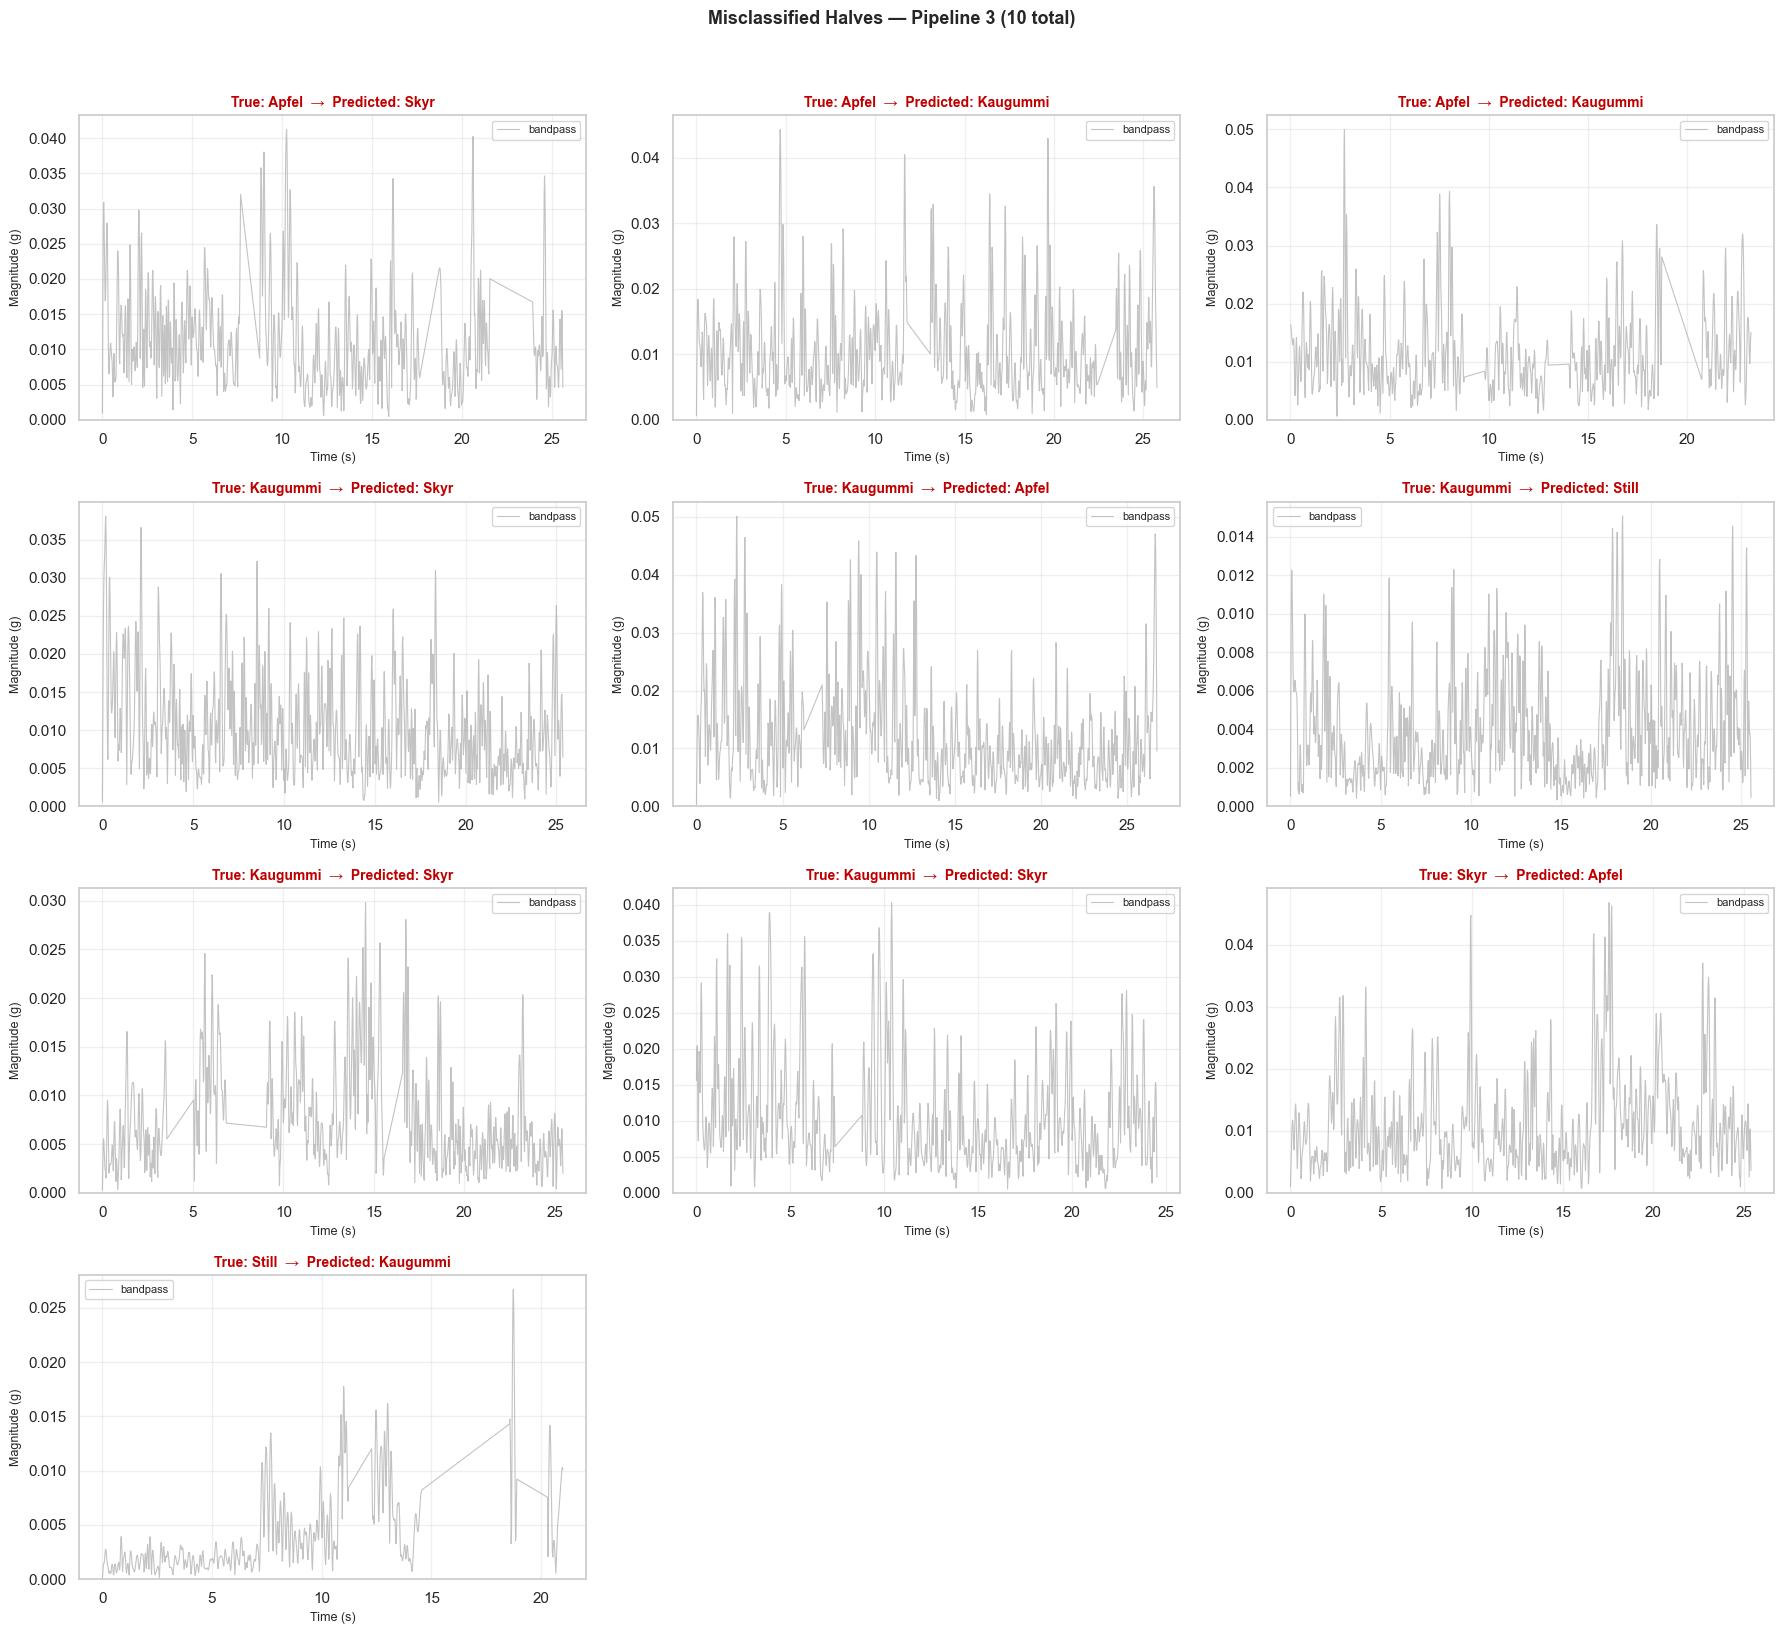

In [11]:
# Rebuild ordered list matching X3 / y3 rows
half_refs3 = []
for cls in CLASSES:
    for df in halved_bp_nomov[cls]:
        half_refs3.append((df, cls))

# Original (unfiltered) halves in same order for raw signal
half_refs_raw = []
for cls in CLASSES:
    for df in halved[cls][:len(halved_bp_nomov[cls])]:
        half_refs_raw.append((df, cls))

wrong = [(i, yt3[i], yp3[i]) for i in range(len(yt3)) if yt3[i] != yp3[i]]

print(f'{len(wrong)} misclassified half(ves) in Pipeline 3:')
for i, true, pred in wrong:
    print(f'  half {i:3d} | true={true:10s} pred={pred}')

if not wrong:
    print('All halves classified correctly!')
else:
    ncols = min(3, len(wrong))
    nrows = (len(wrong) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             squeeze=False)
    for ax, (i, true, pred) in zip(axes.flatten(), wrong):
        df_clean = half_refs3[i][0]
        t = df_clean['seconds_elapsed'] - df_clean['seconds_elapsed'].iloc[0]
        ax.plot(t, df_clean['magnitude'].values,
                color='#aaaaaa', linewidth=0.8, alpha=0.7, label='bandpass')
        ax.set_title(f'True: {true}  →  Predicted: {pred}',
                     fontsize=10, fontweight='bold', color='#c00000')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.set_ylabel('Magnitude (g)', fontsize=9)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes.flatten()[len(wrong):]:
        ax.set_visible(False)
    fig.suptitle(f'Misclassified Halves — Pipeline 3 ({len(wrong)} total)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()